<a href="https://colab.research.google.com/github/PacoDLC/trading-algoritmico-a-z-con-python/blob/main/ES_TA_Cap%C3%ADtulo_08_bis_Aplicaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p><img alt="Colaboratory logo" height="45px" src="https://www.quantreo.com/wp-content/uploads/2021/10/Original-on-Transparent.png" align="left" hspace="10px" vspace="0px">
<img alt="Colaboratory logo" height="45px" src="https://static-881c.kxcdn.com/wp-content/uploads/2016/03/frogamesLogoFull4.png" align="left" hspace="10px" vspace="0px"></p>

#  Machine Learning con estrategia Intra Diaria


<br>


💰 Únete a la comunidad de [Discord](https://discord.gg/z3dx5XpkX4)

📚 Puedes leer nuestro libro en [Amazon](https://www.amazon.es/Python-para-finanzas-trading-algor%C3%ADtmico-ebook/dp/B0BT4ZS9Q3/)

🖥️ El canal de [YouTube de Quantreo's](https://www.youtube.com/channel/UCp7jckfiEglNf_Gj62VR0pw) (en inglés) y el de [Frogames](https://www.youtube.com/channel/UCMUxXNYrVCv6-bQakhomvBg) en español




In [1]:
! pip install yfinance
! pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=331120272758ddf0f6757724724a804d63cd8b8ce274bdd26f18e02830f2ac6d
  Stored in directory: /root/.cache/pip/wheels/a1/d7/29/7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#plt.style.use('seaborn')
import warnings
warnings.filterwarnings("ignore")
import yfinance as yf
import ta

In [4]:
import matplotlib as mpl
from matplotlib import cycler

colors = cycler('color',
                ['#669FEE', '#66EE91', '#9988DD',
                 '#EECC55', '#88BB44', '#FFBBBB'])
plt.rc('figure', facecolor='#313233')
plt.rc('axes', facecolor="#313233", edgecolor='none',
       axisbelow=True, grid=True, prop_cycle=colors,
       labelcolor='gray')
plt.rc('grid', color='474A4A', linestyle='solid')
plt.rc('xtick', color='gray')
plt.rc('ytick', direction='out', color='gray')
plt.rc('legend', facecolor="#313233", edgecolor="#313233")
plt.rc("text", color="#C9C9C9")
plt.rc('figure', facecolor='#313233')

# Funciones

In [5]:
def lin_reg_trading(symbol):

  def preprocessing_min(name):
    # Import the data
    df = pd.read_csv(name, delimiter="\t", index_col=["<DATE>","<TIME>"] , parse_dates=True).dropna()
    # Delete the two last columns
    df = df.iloc[:,:-2]
    # Rename
    df.columns = ["open", "high", "low", "close", "volume"]
    #df.index.name = "time"

    return df

  def feature_engineering(df):
    """ Crear nuevas variables"""
    # We copy the dataframe to avoid interferences in the data
    df_copy = df.dropna().copy()
    # Create the returns
    df_copy["returns"] = df_copy["close"].pct_change(1)
    # Create the SMAs
    df_copy["SMA 15"] = df_copy[["close"]].rolling(15).mean().shift(1)
    df_copy["SMA 60"] = df_copy[["close"]].rolling(60).mean().shift(1)
    # Create the volatilities
    df_copy["MSD 10"] = df_copy[["returns"]].rolling(10).std().shift(1)
    df_copy["MSD 30"] = df_copy[["returns"]].rolling(30).std().shift(1)
    # Create the Rsi
    RSI = ta.momentum.RSIIndicator(df_copy["close"], window= 14, fillna = False)
    df_copy["rsi"] = RSI.rsi()

    return df_copy.dropna()

  # Import the data
  df = preprocessing_min(symbol)
  dfc = feature_engineering(df)
  # Percentage train set
  split = int(0.80*len(dfc))
  # Train set creation
  X_train = dfc[['SMA 15', 'SMA 60', 'MSD 10', 'MSD 30', 'rsi']].iloc[:split]
  y_train = dfc[["returns"]].iloc[:split]
  # Test set creation
  X_test = dfc[['SMA 15', 'SMA 60', 'MSD 10', 'MSD 30', 'rsi']].iloc[split:]
  y_test = dfc[["returns"]].iloc[split:]
  # Import the class
  from sklearn.linear_model import LinearRegression
  # Initialize the class
  reg = LinearRegression()
  # Fit the model
  reg.fit(X_train, y_train)
  # Create predictions for the whole dataset
  X = np.concatenate((X_train, X_test), axis=0)
  dfc["prediction"] = reg.predict(X)
  # Compute the position
  dfc["position"] = np.sign(dfc["prediction"])
  # Compute the returns
  dfc["strategy"] = dfc["returns"] * dfc["position"].shift(1)

  return dfc["strategy"][dfc["strategy"]<0.50]

# Aplicación

In [6]:
raw_BTCUSD = "https://raw.githubusercontent.com/PacoDLC/trading-algoritmico-a-z-con-python/refs/heads/main/CRYPTO%20H1/BTCUSD_H1.csv"
raw_ETHUSD = "https://raw.githubusercontent.com/PacoDLC/trading-algoritmico-a-z-con-python/refs/heads/main/CRYPTO%20H1/ETHUSD_H1.csv"

<Axes: xlabel='<DATE>,<TIME>'>

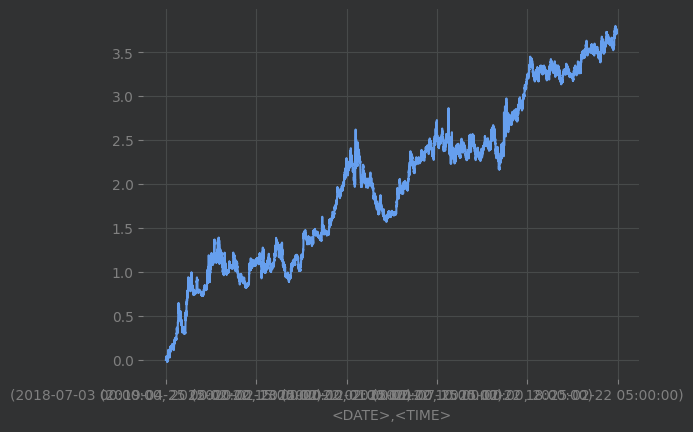

In [7]:
 lin_reg_trading(raw_ETHUSD).cumsum().plot()

<Axes: xlabel='<DATE>,<TIME>'>

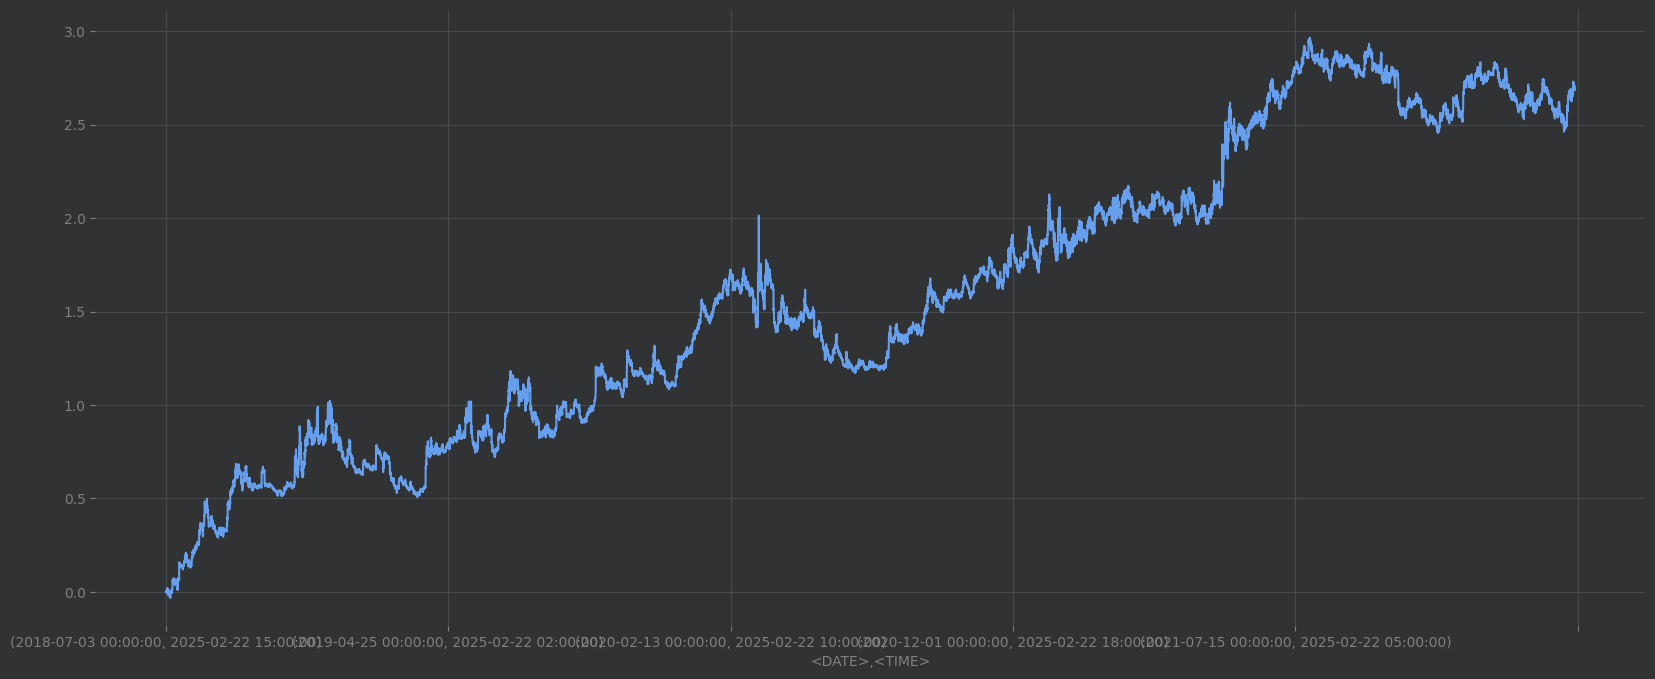

In [8]:
# List of assets
listnames = [raw_BTCUSD, raw_ETHUSD]
returns = pd.DataFrame()

# Compute the return of each strategy
for name in listnames:
  returns[name] = lin_reg_trading(name)

# Plot the results
(returns.dropna().sum(axis=1)/returns.shape[1]).cumsum().plot(figsize=(20,8))

In [9]:
pf = returns.dropna().sum(axis=1)/returns.shape[1]

In [10]:
def drawdown_function(serie):

  # We compute Cumsum of the returns
  cum = serie.dropna().cumsum() + 1

  # We compute max of the cumsum on the period (accumulate max) # (1,3,5,3,1) --> (1,3,5,5,5)
  running_max = np.maximum.accumulate(cum)

  # We compute drawdown
  drawdown = cum/running_max - 1
  return drawdown

In [11]:
(pf.dropna().cumsum().iloc[-1]) / -np.min(drawdown_function(pf.dropna()))

9.63760692141075